# Logistic Regression — Heart Disease Prediction
**Module:** IT5052 – Fundamentals of Machine Learning  
**Program:** MSc in Artificial Intelligence, SLIIT (2026/JAN)  

This notebook continues from the preprocessing pipeline.  
Pre-split, pre-scaled data is loaded from `output/csv/`.

## 1. Dataset Description

The dataset used in this project is the Heart Disease Prediction Dataset, sourced from Kaggle. It is accessible at: https://www.kaggle.com/datasets/oktayrdeki/heart-disease
The dataset is a  records for heart disease prediction research and machine learning experimentation. It represents a wide spectrum of cardiovascular risk factors  including  laboratory outcomes, lifestyle, and related clinical conditions.


### Feature groups

* **Numeric** — Age, Cholesterol Level, BMI, Blood Pressure, Sleep Hours, Triglyceride Level, Fasting Blood Sugar, CRP Level, Homocysteine Level
* **Binary categorical** — Gender, Smoking, Family Heart Disease, Diabetes, High Blood Pressure, Low HDL Cholesterol, High LDL Cholesterol.
* **Ordinal categorical** — Exercise Habits, Alcohol Consumption, Stress Level, Sugar Consumption (Low &lt; Medium &lt; High).
* **Target** — `Heart Disease Status` (Yes / No).

## 2. Setup 

In [912]:
#Data handling
import pandas as pd
import numpy as np

#Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer


# Persistence
import joblib

# Ignore warnings
import warnings


# path handling
import os
import pathlib as path

import logging
import json
import io


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Output handling
output_dir = path.Path(os.getcwd()).parent / "output" / "csv"
plot_dir   = path.Path(os.getcwd()).parent / "output" / "plots"   
model_dir  = path.Path(os.getcwd()).parent / "output" / "model"



In [913]:
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['savefig.dpi']    = 120
plt.rcParams['savefig.bbox']   = 'tight'


In [914]:
# Create folder if not exists
output_dir.mkdir(parents=True, exist_ok=True)
plot_dir.mkdir(parents=True, exist_ok=True)
model_dir.mkdir(parents=True, exist_ok=True)

print("CSV   output:", output_dir)
print("Plot  output:", plot_dir)
print("Model output:", model_dir)


CSV   output: d:\Master of Science Artificial Intelligence\Semester - 01\IT5022 - Fundamentals of Machine Learning\Group assignment\Machine-Learning-Programming-Assignment-IT5052\output\csv
Plot  output: d:\Master of Science Artificial Intelligence\Semester - 01\IT5022 - Fundamentals of Machine Learning\Group assignment\Machine-Learning-Programming-Assignment-IT5052\output\plots
Model output: d:\Master of Science Artificial Intelligence\Semester - 01\IT5022 - Fundamentals of Machine Learning\Group assignment\Machine-Learning-Programming-Assignment-IT5052\output\model


## 3. Logging

In [915]:
log_dir = path.Path(os.getcwd()).parent / "output" / "logs"
log_dir.mkdir(parents=True, exist_ok=True)

log_file = log_dir / "app.log"

for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

# Setup logging
logging.basicConfig(
    filename=log_file,
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - [Preprocessing] - %(message)s"
)

logger = logging.getLogger(__name__)
logger.info("=" * 60)
logger.info("Preprocessing notebook started.")

 ## 4. Load Data

In [916]:
dataSetPath = path.Path(os.getcwd()).parent / "data" / "supervised_learning" / "heart_disease.csv"
#print(f"Dataset path: {dataSetPath}")
df = pd.read_csv(dataSetPath)
logger.info(f"Dataset loaded successfully with shape: {df.shape}")
print("Dataset shape:", df.shape)

Dataset shape: (10000, 21)


In [917]:
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


## 5. Basic Analysis

In [918]:
#logger.info(df.info())
buf = io.StringIO()
df.info(buf=buf)
info_str = buf.getvalue()
print(info_str)
logger.info("df.info():\n" + info_str)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   object 
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   object 
 5   Smoking               9975 non-null   object 
 6   Family Heart Disease  9979 non-null   object 
 7   Diabetes              9970 non-null   object 
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   object 
 10  Low HDL Cholesterol   9975 non-null   object 
 11  High LDL Cholesterol  9974 non-null   object 
 12  Alcohol Consumption   7414 non-null   object 
 13  Stress Level          9978 non-null   object 
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption   

In [919]:
df.describe()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
count,9971.000000,9981.000000,9970.000000,9978.000000,9975.000000,9974.000000,9978.000000,9974.000000,9980.000000
mean,49.296259,149.757740,225.425577,29.077269,6.991329,250.734409,120.142213,7.472201,12.456271
std,18.193970,17.572969,43.575809,6.307098,1.753195,87.067226,23.584011,4.340248,4.323426
min,18.000000,120.000000,150.000000,18.002837,4.000605,100.000000,80.000000,0.003647,5.000236
25%,34.000000,134.000000,187.000000,23.658075,5.449866,176.000000,99.000000,3.674126,8.723334
50%,49.000000,150.000000,226.000000,29.079492,7.003252,250.000000,120.000000,7.472164,12.409395
75%,65.000000,165.000000,263.000000,34.520015,8.531577,326.000000,141.000000,11.255592,16.140564
max,80.000000,180.000000,300.000000,39.996954,9.999952,400.000000,160.000000,14.997087,19.999037


In [920]:
# Summary of categorical (object) columns
df.describe(include='object')

,Gender,Exercise Habits,Smoking,Family Heart Disease,Diabetes,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sugar Consumption,Heart Disease Status
count,9981,9975,9975,9979,9970,9974,9975,9974,7414,9978,9970,10000
unique,2,3,2,2,2,2,2,2,3,3,3,2
top,Male,High,Yes,No,No,Yes,Yes,No,Medium,Medium,Low,No
freq,5003,3372,5123,5004,5018,5022,5000,5036,2500,3387,3390,8000


## 5.1 Unique Values per column

In [921]:
for col in df.columns:
    print(col, df[col].unique())

Age [56. 69. 46. 32. 60. 25. 78. 38. 75. 36. 40. 28. 41. 70. 53. 57. 20. 39.
 19. 61. 47. 55. 77. 50. 29. 42. 66. 44. 76. 80. 59. 45. 33. 79. 64. 68.
 72. 74. 54. 24. 26. 35. 21. 31. 67. 43. 37. 52. 34. 23. 71. 51. 27. 48.
 65. 62. 58. 18. 22. 30. 49. 73. 63. nan]
Gender ['Male' 'Female' nan]
Blood Pressure [153. 146. 126. 122. 166. 152. 121. 161. 135. 144. 179. 134. 143. 150.
 133. 173. 125. 136. 137. 139. 170. 159. 158. 171. 151. 163. 128. 165.
 129. 168. 155. 142. 127. 132. 176. 141. 160. 154. 164. 138. 149. 178.
 140. 147.  nan 175. 162. 157. 174. 123. 145. 124. 148. 169. 172. 167.
 131. 120. 177. 130. 180. 156.]
Cholesterol Level [155. 286. 216. 293. 242. 257. 175. 187. 291. 252. 191. 296. 215. 290.
 255. 245. 219. 246. 268. 300. 223. 206. 259. 228. 185. 278. 152. 163.
 183. 218. 253. 178. 197. 243. 266. 287. 281. 224. 177. 270. 158. 283.
 272. 198. 240. 274. 225. 299. 298. 182. 202. 189. 167. 162. 254. 280.
 151. 284. 292. 288. 277. 176. 170. 157. 232. 204. 199. 261. 295. 179.
 1

## 5.2 Missing Values

In [922]:
#df.isnull().sum()
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    "missing_count": missing,
    "missing_pct"  : missing_pct
})
missing_table = missing_table[missing_table["missing_count"] > 0]
print(missing_table)
logger.info(f"Columns with missing values: {len(missing_table)}")


                      missing_count  missing_pct
Alcohol Consumption            2586        25.86
Cholesterol Level                30         0.30
Sugar Consumption                30         0.30
Diabetes                         30         0.30
Age                              29         0.29
High LDL Cholesterol             26         0.26
CRP Level                        26         0.26
Triglyceride Level               26         0.26
High Blood Pressure              26         0.26
Sleep Hours                      25         0.25
Low HDL Cholesterol              25         0.25
Smoking                          25         0.25
Exercise Habits                  25         0.25
BMI                              22         0.22
Stress Level                     22         0.22
Fasting Blood Sugar              22         0.22
Family Heart Disease             21         0.21
Homocysteine Level               20         0.20
Gender                           19         0.19
Blood Pressure      

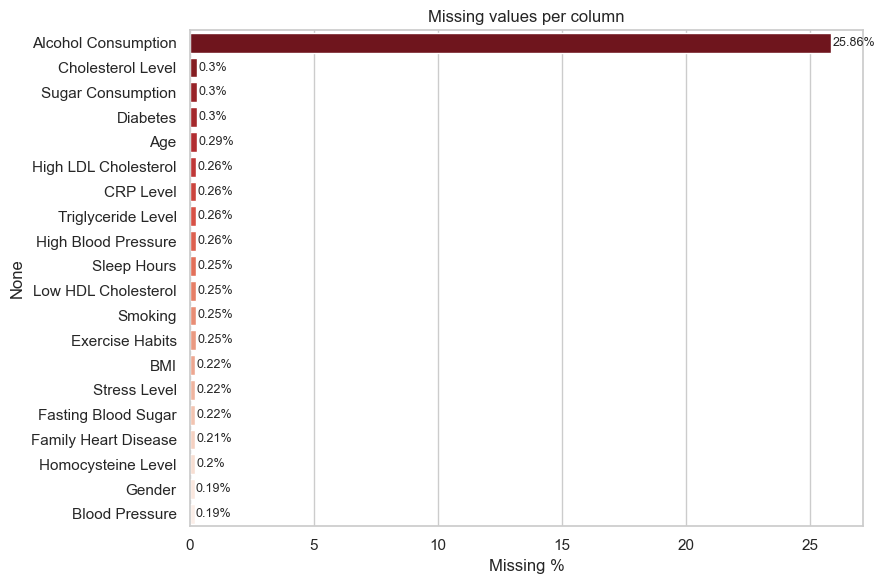

In [923]:
# Visualise missing values (saved for the report)
if len(missing_table) > 0:
    fig, ax = plt.subplots(figsize=(9, max(4, 0.3 * len(missing_table))))
    sns.barplot(x=missing_table["missing_pct"],
                y=missing_table.index,
                palette="Reds_r", ax=ax)
    ax.set_xlabel("Missing %")
    ax.set_title("Missing values per column")
    for i, v in enumerate(missing_table["missing_pct"].values):
        ax.text(v + 0.05, i, f"{v}%", va="center", fontsize=9)
    plt.tight_layout()
    plt.savefig(plot_dir / "01_missing_values.png")
    plt.show()
else:
    print("No missing values.")


## 5.3 Duplication Check

In [924]:
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")

logger.info(f"Duplicate rows: {dup_count}")

# Drop duplicates if any (keeps first occurrence)
if dup_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Removed duplicates. New shape: {df.shape}")
    logger.info(f"After de-dup, shape: {df.shape}")

Duplicate rows: 0


## 6. Exploratory Data Analysis (EDA)

Class counts:
                      count  percent
Heart Disease Status                
No                     8000     80.0
Yes                    2000     20.0


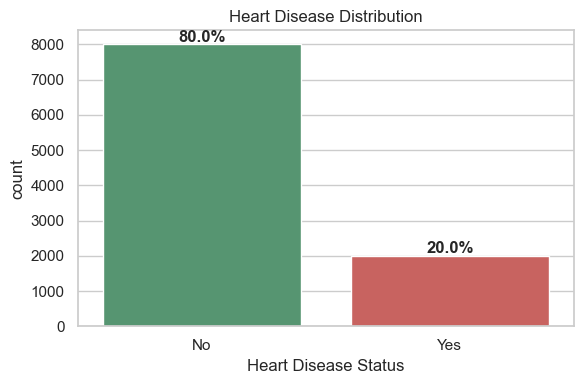


Imbalance ratio (majority : minority) = 4.00 : 1


In [925]:
target_counts = df['Heart Disease Status'].value_counts()
target_pct    = (target_counts / len(df) * 100).round(2)

print("Class counts:")
print(pd.DataFrame({"count": target_counts, "percent": target_pct}))

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x='Heart Disease Status', data=df,
              palette=["#4C9F70", "#D9534F"], ax=ax)
ax.set_title("Heart Disease Distribution")
for i, v in enumerate(target_counts.values):
    ax.text(i, v + max(target_counts.values) * 0.01,
            f"{target_pct.iloc[i]}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(plot_dir / "02_target_distribution.png")
plt.show()

imbalance_ratio = target_counts.max() / target_counts.min()
print(f"\nImbalance ratio (majority : minority) = {imbalance_ratio:.2f} : 1")
logger.info(f"Class imbalance ratio: {imbalance_ratio:.2f}:1")


### 6.2 Age Distribution

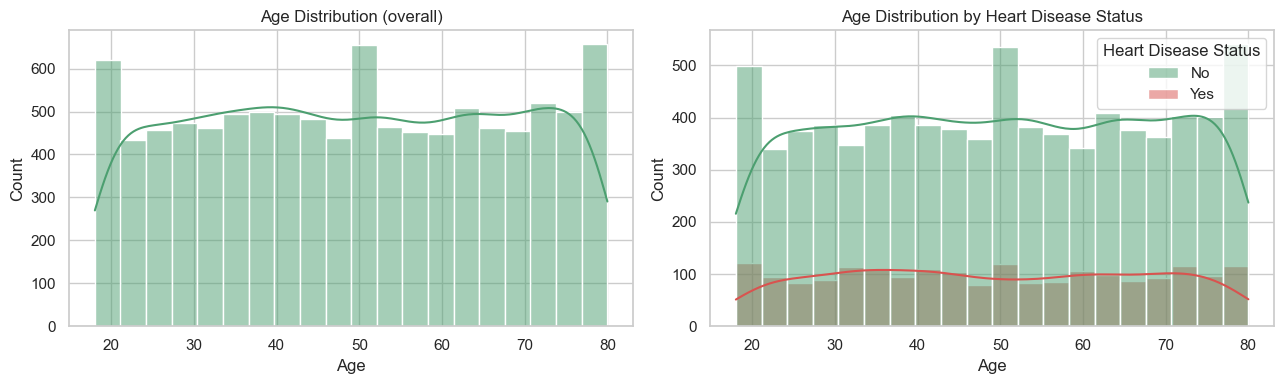

In [926]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Overall age distribution
sns.histplot(df['Age'], bins=20, kde=True, color="#4C9F70", ax=axes[0])
axes[0].set_title("Age Distribution (overall)")

# Age distribution by target
sns.histplot(data=df, x='Age', hue='Heart Disease Status',
             bins=20, kde=True, palette=["#4C9F70", "#D9534F"], ax=axes[1])
axes[1].set_title("Age Distribution by Heart Disease Status")

plt.tight_layout()
plt.savefig(plot_dir / "03_age_distribution.png")
plt.show()

### 6.3 Numeric Features - Distributions

In [927]:
# Detect numeric columns (excluding the target)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Heart Disease Status' in numeric_cols:
    numeric_cols.remove('Heart Disease Status')

print(f"Numeric features ({len(numeric_cols)}):", numeric_cols)

Numeric features (9): ['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level']


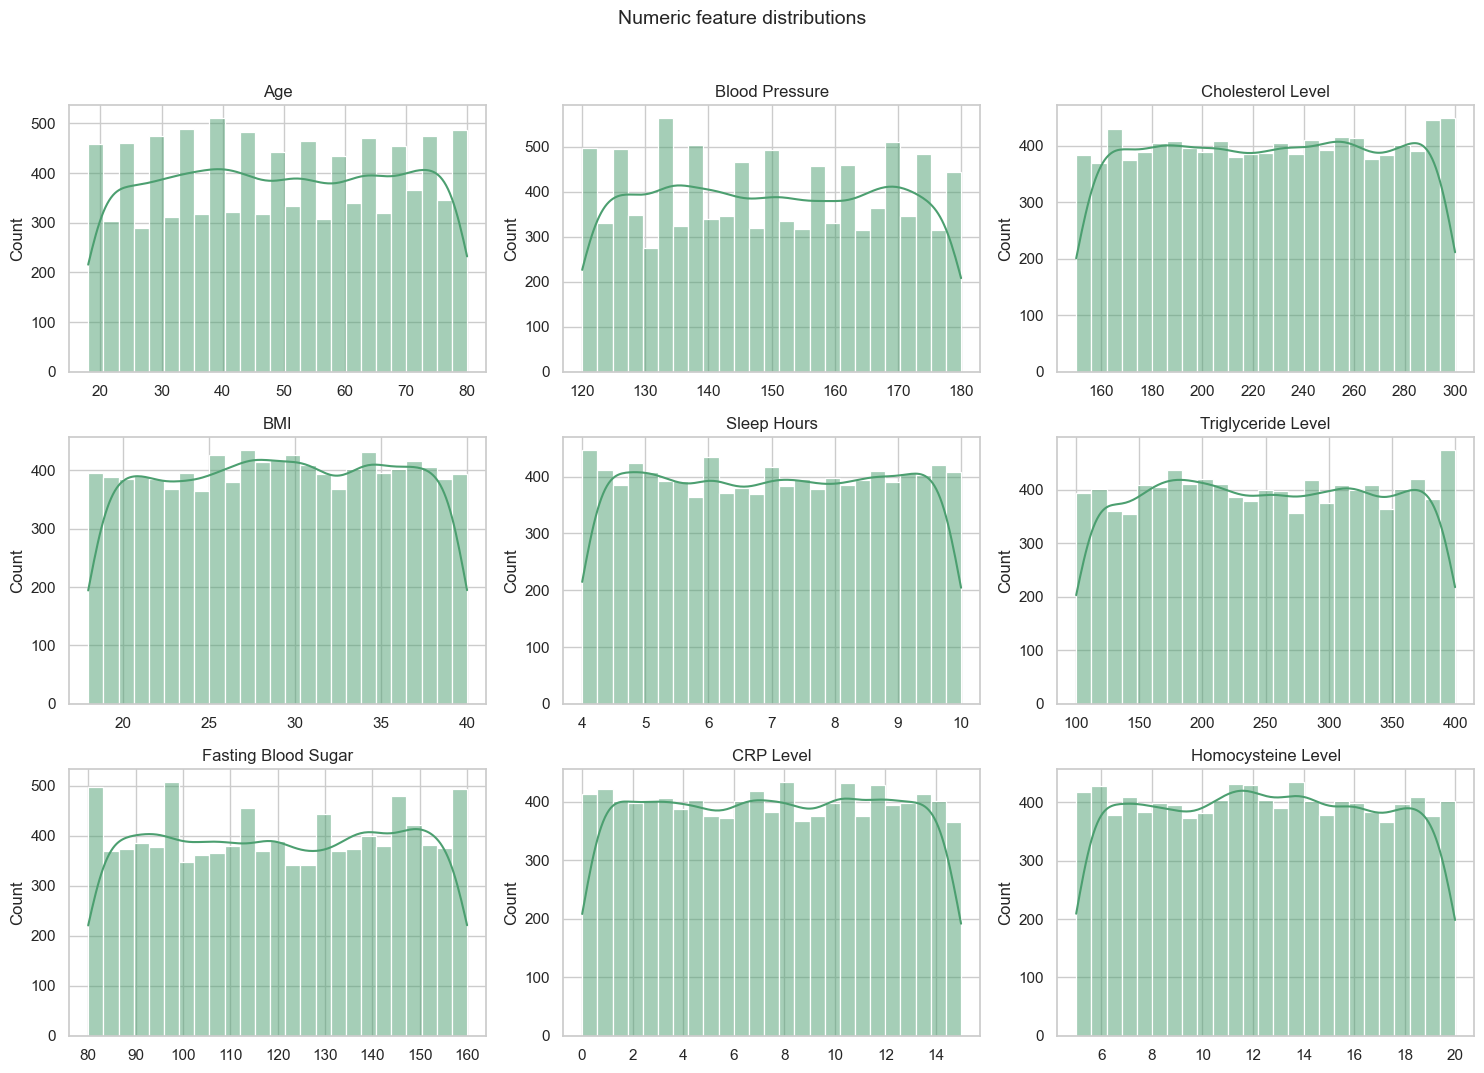

In [928]:
# Grid of histograms - one per numeric feature
n = len(numeric_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.5 * nrows))
axes = axes.flatten() if n > 1 else [axes]

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), bins=25, kde=True,
                 color="#4C9F70", ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("")

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeric feature distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(plot_dir / "04_numeric_distributions.png")
plt.show()


### 6.4 Outlier Analysis

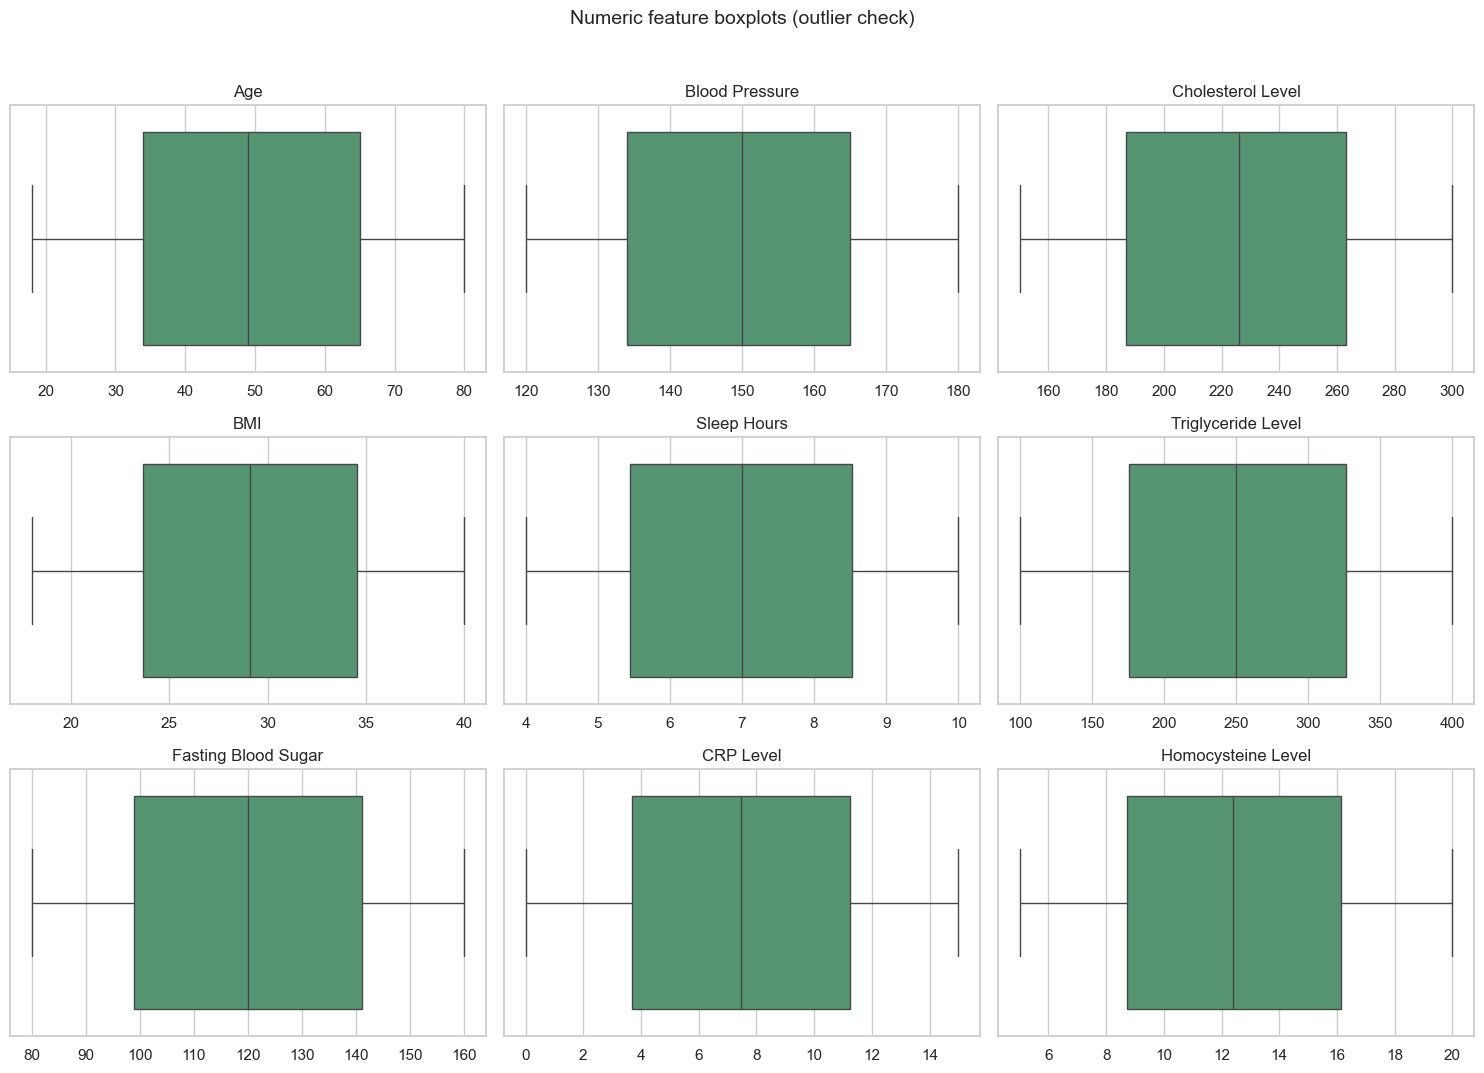

In [929]:
# Boxplots - one per numeric feature
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.5 * nrows))
axes = axes.flatten() if n > 1 else [axes]

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], color="#4C9F70", ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeric feature boxplots (outlier check)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(plot_dir / "05_numeric_boxplots.png")
plt.show()

In [930]:
# Count outliers per numeric feature using IQR rule
def count_outliers_iqr(series):
    s = series.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((s < lower) | (s > upper)).sum()

outlier_table = pd.DataFrame({
    "outlier_count": [count_outliers_iqr(df[c]) for c in numeric_cols],
    "outlier_pct"  : [round(count_outliers_iqr(df[c]) / df[c].notna().sum() * 100, 2)
                      for c in numeric_cols],
}, index=numeric_cols).sort_values("outlier_count", ascending=False)

print(outlier_table)
logger.info(f"Outlier summary (IQR):\n{outlier_table}")

                     outlier_count  outlier_pct
Age                              0          0.0
Blood Pressure                   0          0.0
Cholesterol Level                0          0.0
BMI                              0          0.0
Sleep Hours                      0          0.0
Triglyceride Level               0          0.0
Fasting Blood Sugar              0          0.0
CRP Level                        0          0.0
Homocysteine Level               0          0.0


### 6.5 Numeric Features Stratified by Target

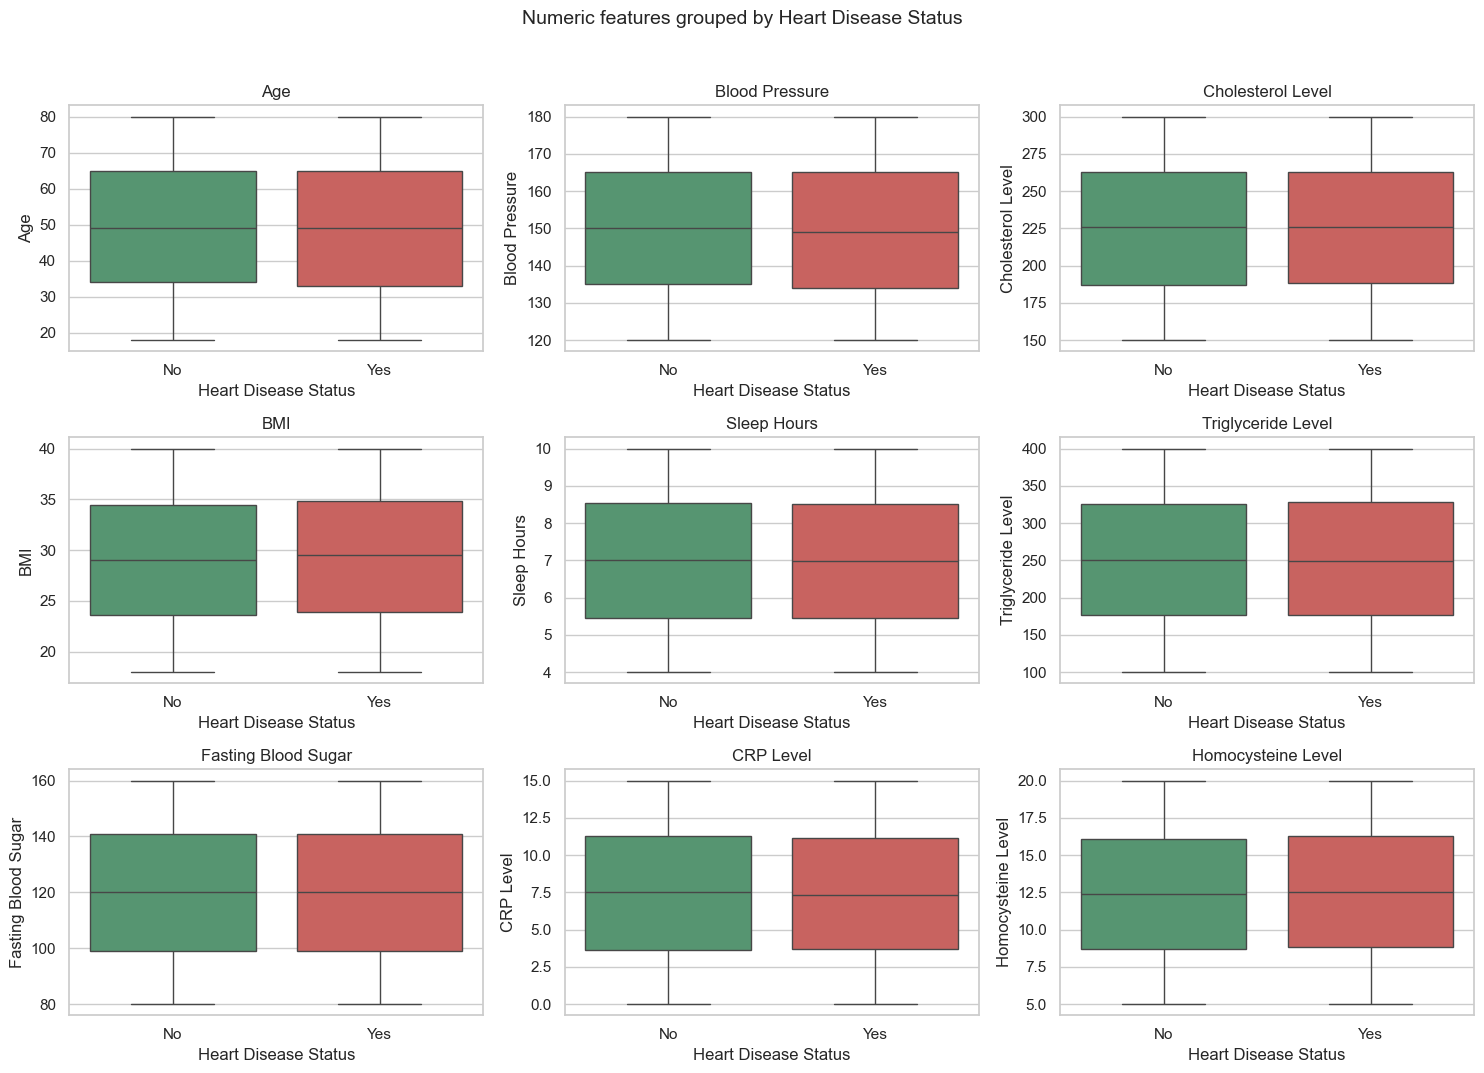

In [931]:
# Boxplot of each numeric feature broken down by Heart Disease Status -
# helps spot which features differ between sick and healthy patients.
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.5 * nrows))
axes = axes.flatten() if n > 1 else [axes]

for i, col in enumerate(numeric_cols):
    sns.boxplot(x='Heart Disease Status', y=col, data=df,
                palette=["#4C9F70", "#D9534F"], ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeric features grouped by Heart Disease Status",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(plot_dir / "06_numeric_by_target.png")
plt.show()


### 6.6 Feature Correlation Matrix

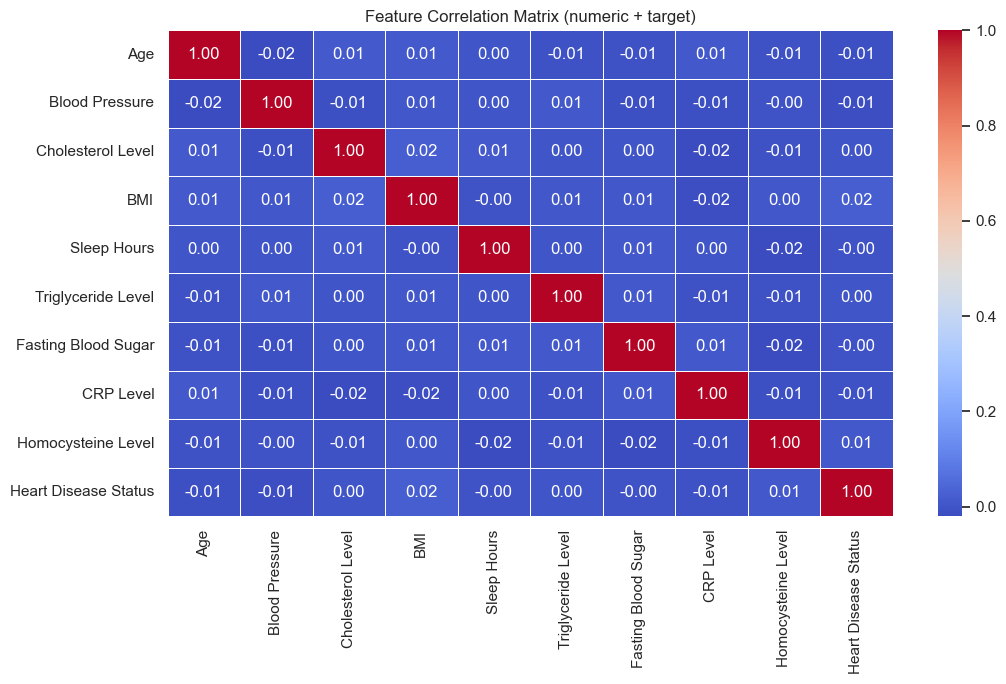

In [932]:
plt.figure(figsize=(11, 7))

# Include encoded target (0/1) so we can also see correlation with the label
corr_df = df.copy()
corr_df['Heart Disease Status'] = corr_df['Heart Disease Status'].map({'No': 0, 'Yes': 1})
numeric_corr = corr_df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_corr.corr(), annot=True, cmap='coolwarm',
            linewidths=0.5, fmt=".2f")
plt.title("Feature Correlation Matrix (numeric + target)")
plt.tight_layout()
plt.savefig(plot_dir / "07_correlation_heatmap.png")
plt.show()


### 6.7 Categorical Features by Target

Categorical features (11): ['Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level', 'Sugar Consumption']


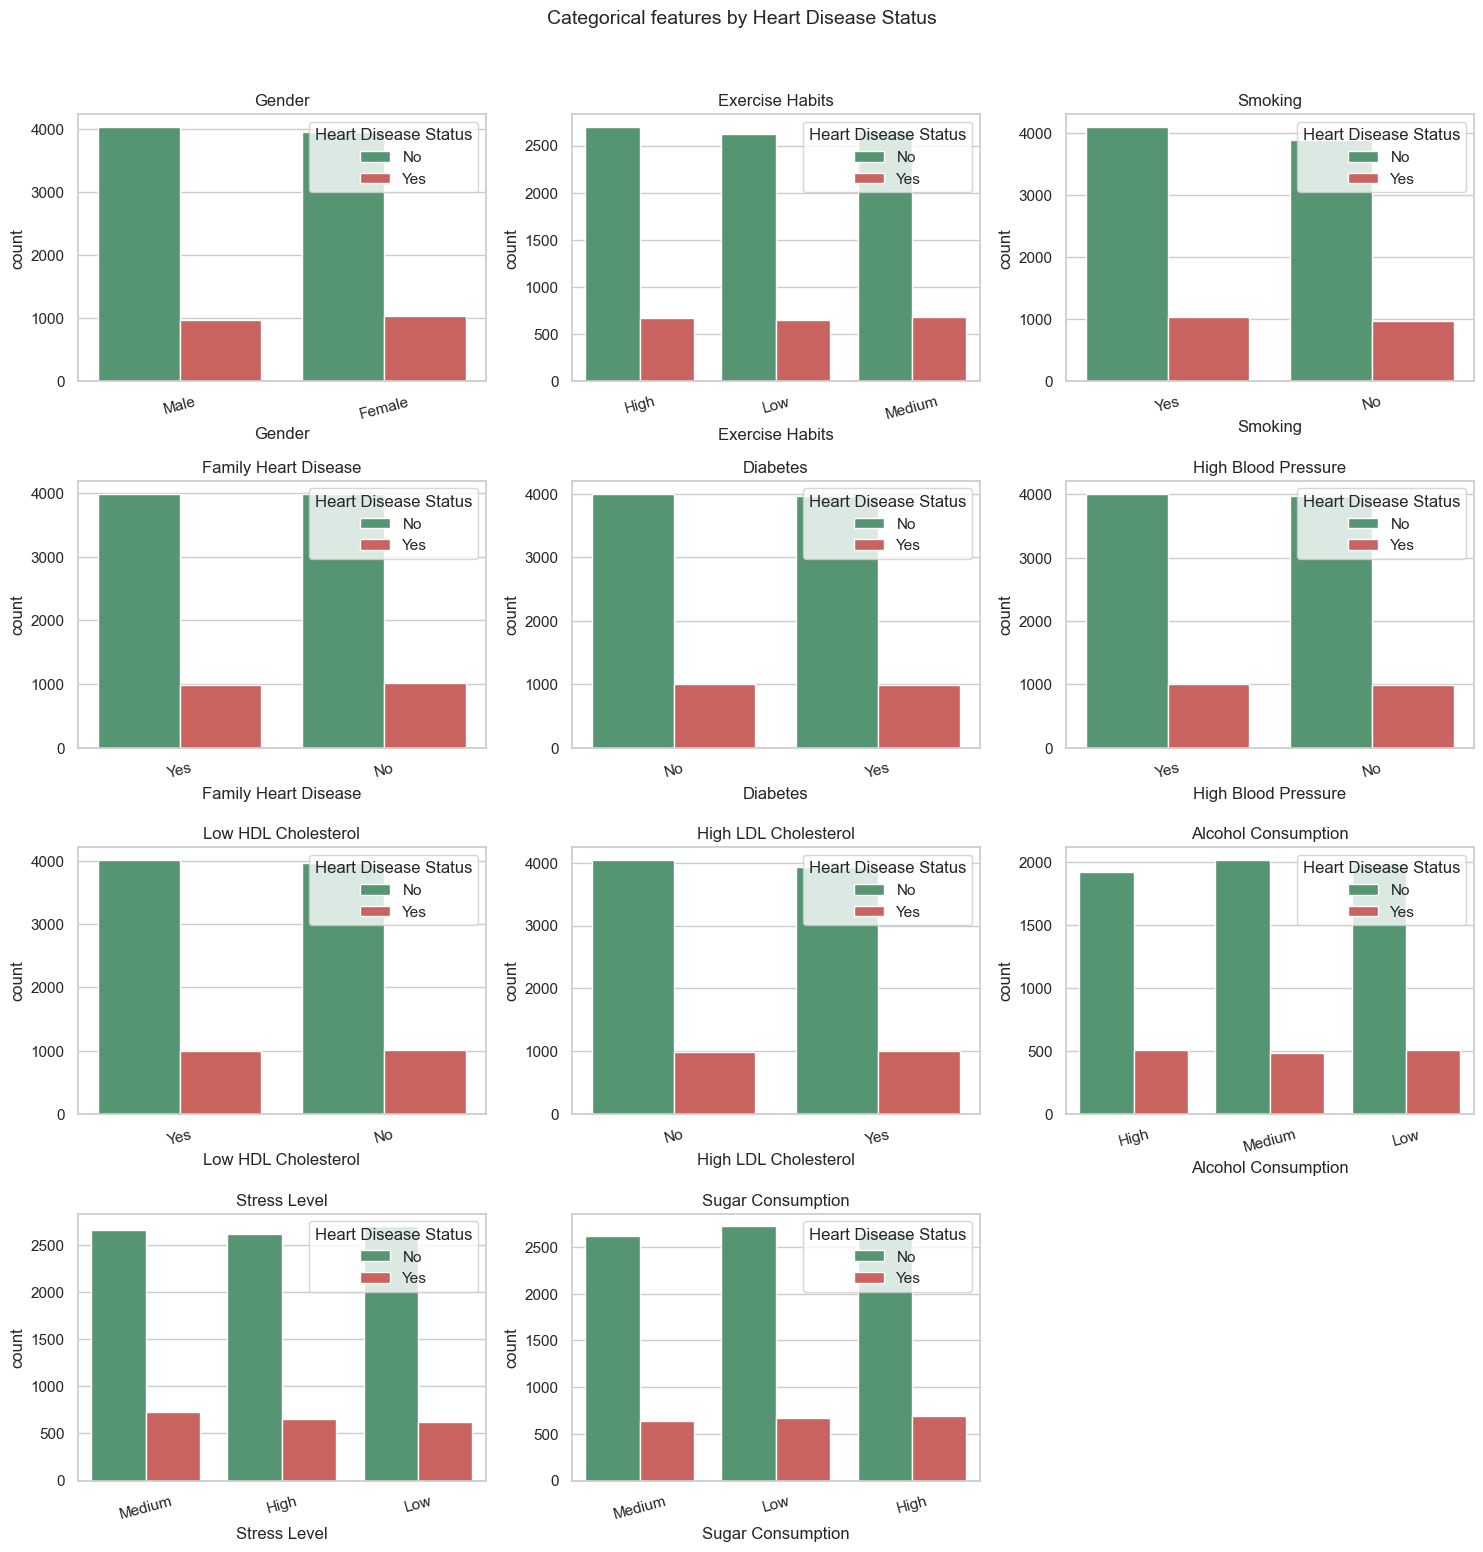

In [933]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
if 'Heart Disease Status' in cat_cols:
    cat_cols.remove('Heart Disease Status')

print(f"Categorical features ({len(cat_cols)}):", cat_cols)

ncols_cat = 3
nrows_cat = (len(cat_cols) + ncols_cat - 1) // ncols_cat
fig, axes = plt.subplots(nrows_cat, ncols_cat,
                          figsize=(15, 3.8 * nrows_cat))
axes = axes.flatten() if len(cat_cols) > 1 else [axes]

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue='Heart Disease Status', data=df,
                  palette=["#4C9F70", "#D9534F"], ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=15)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Categorical features by Heart Disease Status",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(plot_dir / "08_categorical_by_target.png")
plt.show()


### 6.8 Age vs Cholesterol (scatter, coloured by target)

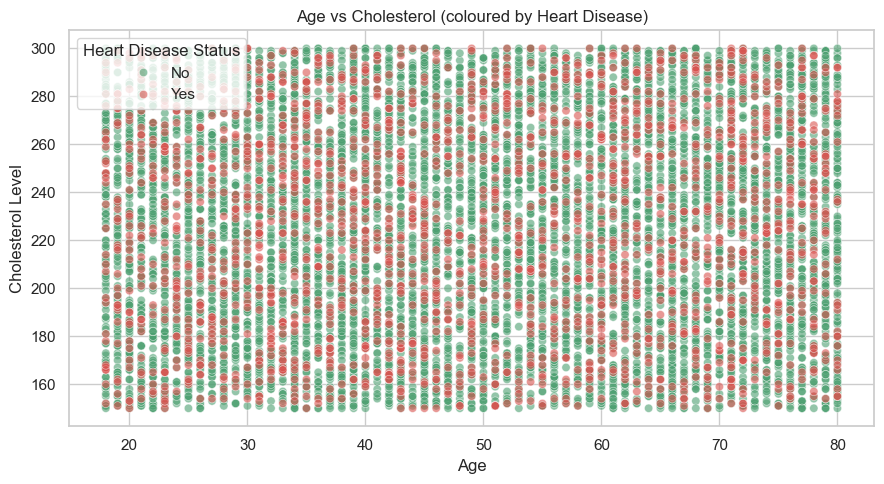

In [934]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(x='Age', y='Cholesterol Level',
                hue='Heart Disease Status',
                palette=["#4C9F70", "#D9534F"],
                alpha=0.6, data=df, ax=ax)
ax.set_title("Age vs Cholesterol (coloured by Heart Disease)")
plt.tight_layout()
plt.savefig(plot_dir / "09_age_vs_cholesterol.png")
plt.show()


# 7. Data Preprocessing

### 7.1 Encode Target

In [935]:
print(df['Heart Disease Status'].value_counts())

Heart Disease Status
No     8000
Yes    2000
Name: count, dtype: int64


In [936]:
df['Heart Disease Status'] = df['Heart Disease Status'].map({'No':0, 'Yes':1})

print("\nAfter encoding:")
print(df['Heart Disease Status'].value_counts())
logger.info("Target encoded: No -> 0, Yes -> 1")


After encoding:
Heart Disease Status
0    8000
1    2000
Name: count, dtype: int64


### 7.2 Separate Features and Target

In [937]:
# Separate features and target
X = df.drop('Heart Disease Status', axis=1)
y = df['Heart Disease Status']


logger.info(f"Features shape: {X.shape}, Target shape: {y.shape}")
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (10000, 20)
Target shape: (10000,)


### 7.3 Define Column Groups

In [938]:
categorical_cols = X.select_dtypes(include='object').columns
categorical_cols

Index(['Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease',
       'Diabetes', 'High Blood Pressure', 'Low HDL Cholesterol',
       'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level',
       'Sugar Consumption'],
      dtype='object')

In [939]:
categorical_cols_all = X[categorical_cols].apply(lambda x: x.unique())

print(categorical_cols_all)

Gender                       [Male, Female, nan]
Exercise Habits         [High, Low, Medium, nan]
Smoking                           [Yes, No, nan]
Family Heart Disease              [Yes, No, nan]
Diabetes                          [No, Yes, nan]
High Blood Pressure               [Yes, No, nan]
Low HDL Cholesterol               [Yes, No, nan]
High LDL Cholesterol              [No, Yes, nan]
Alcohol Consumption     [High, Medium, Low, nan]
Stress Level            [Medium, High, Low, nan]
Sugar Consumption       [Medium, Low, High, nan]
dtype: object


In [940]:
# Numeric columns are detected dynamically (more robust than hard-coding)
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Define binary and ordinal columns based on characteristics of the data
binary_cols = [
    'Gender',
    'Smoking',
    'Family Heart Disease',
    'Diabetes',
    'High Blood Pressure',
    'Low HDL Cholesterol',
    'High LDL Cholesterol'
]

ordinal_cols = [
    'Exercise Habits',
    'Alcohol Consumption',
    'Stress Level',
    'Sugar Consumption'
]

# Sanity check: every column should be classified
classified = set(numeric_cols) | set(binary_cols) | set(ordinal_cols)
unclassified = set(X.columns) - classified
assert not unclassified, f"Unclassified columns: {unclassified}"

print(f"Numeric : {len(numeric_cols)} cols")
print(f"Binary  : {len(binary_cols)} cols")
print(f"Ordinal : {len(ordinal_cols)} cols")



Numeric : 9 cols
Binary  : 7 cols
Ordinal : 4 cols


### 7.4 Stratified Train / Test Split

In [941]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train size:", X_train.shape, "  positive rate:", round(y_train.mean(), 4))
print("Test  size:", X_test.shape,  "  positive rate:", round(y_test.mean(),  4))
logger.info(f"Train: {X_train.shape}, Test: {X_test.shape}")
logger.info(f"Train pos rate: {y_train.mean():.4f}, Test pos rate: {y_test.mean():.4f}")

Train size: (8000, 20)   positive rate: 0.2
Test  size: (2000, 20)   positive rate: 0.2


### 7.5 Missing Value Imputation

In [942]:
# Numeric: median imputation 
num_imputer = SimpleImputer(strategy='median')
X_train[numeric_cols] = num_imputer.fit_transform(X_train[numeric_cols])
X_test[numeric_cols]  = num_imputer.transform(X_test[numeric_cols])

# Binary + Ordinal: mode imputation
cat_imputer = SimpleImputer(strategy='most_frequent')
X_train[binary_cols + ordinal_cols] = cat_imputer.fit_transform(
    X_train[binary_cols + ordinal_cols])
X_test[binary_cols + ordinal_cols]  = cat_imputer.transform(
    X_test[binary_cols + ordinal_cols])

# Verify no missing values remain
assert X_train.isnull().sum().sum() == 0, "Missing values remain in X_train"
assert X_test.isnull().sum().sum()  == 0, "Missing values remain in X_test"

print("Missing values after imputation -> train:", X_train.isnull().sum().sum(),
      "  test:", X_test.isnull().sum().sum())
logger.info("Missing value handling has been completed (fitted on train only).")

Missing values after imputation -> train: 0   test: 0


In [943]:
print(f"", X_train.isnull().sum())
print(f"", X_test.isnull().sum())

 Age                     0
Gender                  0
Blood Pressure          0
Cholesterol Level       0
Exercise Habits         0
Smoking                 0
Family Heart Disease    0
Diabetes                0
BMI                     0
High Blood Pressure     0
Low HDL Cholesterol     0
High LDL Cholesterol    0
Alcohol Consumption     0
Stress Level            0
Sleep Hours             0
Sugar Consumption       0
Triglyceride Level      0
Fasting Blood Sugar     0
CRP Level               0
Homocysteine Level      0
dtype: int64
 Age                     0
Gender                  0
Blood Pressure          0
Cholesterol Level       0
Exercise Habits         0
Smoking                 0
Family Heart Disease    0
Diabetes                0
BMI                     0
High Blood Pressure     0
Low HDL Cholesterol     0
High LDL Cholesterol    0
Alcohol Consumption     0
Stress Level            0
Sleep Hours             0
Sugar Consumption       0
Triglyceride Level      0
Fasting Blood Sugar    

### 7.6 Categorical Encoding

In [944]:
# Binary encoding (Yes/No, Male/Female)
binary_map = {
    'Yes': 1,
    'No' : 0,
    'Male'  : 1,
    'Female': 0
}

# Ordinal encoding (Low < Medium < High)
ordinal_map = {
    'Low'   : 0,
    'Medium': 1,
    'High'  : 2
}

for col in binary_cols:
    X_train[col] = X_train[col].map(binary_map)
    X_test[col]  = X_test[col].map(binary_map)

for col in ordinal_cols:
    X_train[col] = X_train[col].map(ordinal_map)
    X_test[col]  = X_test[col].map(ordinal_map)

# Catch silent mapping failures: any unmapped value becomes NaN.
assert X_train.isnull().sum().sum() == 0, \
    "Unmapped categorical values in X_train - check binary_map / ordinal_map."
assert X_test.isnull().sum().sum() == 0, \
    "Unmapped categorical values in X_test  - check binary_map / ordinal_map."

logger.info("Encoding of categorical variables has been completed.")
X_train.head()


,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
7395,19.0,1,175.0,272.0,2,0,1,0,28.879776,1,1,0,0,0,9.336435,2,201.0,159.0,5.826202,17.965483
5642,22.0,0,123.0,170.0,2,0,0,0,30.256079,0,1,1,1,2,6.997215,0,335.0,122.0,3.209347,7.662533
8866,45.0,0,158.0,172.0,1,1,1,1,33.965395,1,0,1,1,1,8.946560,0,377.0,109.0,13.295242,19.739923
8517,29.0,1,143.0,292.0,0,1,0,1,21.565885,0,1,0,2,2,9.851365,1,370.0,120.0,0.691456,12.739675
3706,46.0,0,135.0,224.0,0,0,1,0,28.271290,0,0,1,2,2,7.965155,2,351.0,149.0,10.908451,18.198180


### 8.7 Feature Scaling

In [945]:
scaler = StandardScaler()

# Fit on train, transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Wrap back into DataFrames so downstream notebooks keep the column names
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns,
                       index=X_train.index)
X_test  = pd.DataFrame(X_test_scaled,  columns=X_test.columns,
                       index=X_test.index)

print("After scaling (train summary):")
print(X_train.describe().round(3).T[['mean', 'std', 'min', 'max']].head())
logger.info("Feature standardization has been completed (fitted on train only).")

After scaling (train summary):
                   mean  std    min    max
Age                -0.0  1.0 -1.717  1.690
Gender             -0.0  1.0 -0.996  1.004
Blood Pressure     -0.0  1.0 -1.686  1.721
Cholesterol Level   0.0  1.0 -1.739  1.709
Exercise Habits    -0.0  1.0 -1.246  1.209


## 8. Persist Train/Test Sets, Scaler & Metadata

In [946]:
# Save train/test CSVs 
X_train.to_csv(output_dir / "X_train.csv", index=False)
X_test.to_csv (output_dir / "X_test.csv",  index=False)
y_train.to_csv(output_dir / "y_train.csv", index=False)
y_test.to_csv (output_dir / "y_test.csv",  index=False)

# Save fitted transformers (so new patient data can be transformed identically)
joblib.dump(scaler,      model_dir / "scaler.pkl")
joblib.dump(num_imputer, model_dir / "num_imputer.pkl")
joblib.dump(cat_imputer, model_dir / "cat_imputer.pkl")

logger.info("Preprocessed data and transformers have been saved.")
print("CSV files saved to:", output_dir)
print("Transformers saved to:", model_dir)

CSV files saved to: d:\Master of Science Artificial Intelligence\Semester - 01\IT5022 - Fundamentals of Machine Learning\Group assignment\Machine-Learning-Programming-Assignment-IT5052\output\csv
Transformers saved to: d:\Master of Science Artificial Intelligence\Semester - 01\IT5022 - Fundamentals of Machine Learning\Group assignment\Machine-Learning-Programming-Assignment-IT5052\output\model


### 8.1 Save Metadata

In [947]:
eta = {
    "n_features"      : int(X_train.shape[1]),
    "feature_names"   : X_train.columns.tolist(),
    "numeric_cols"    : numeric_cols,
    "binary_cols"     : binary_cols,
    "ordinal_cols"    : ordinal_cols,
    "train_size"      : int(len(X_train)),
    "test_size"       : int(len(X_test)),
    "train_pos_rate"  : float(y_train.mean()),
    "test_pos_rate"   : float(y_test.mean()),
    "imbalance_ratio" : float(imbalance_ratio),
    "random_state"    : RANDOM_STATE,
}

with open(output_dir / "metadata.json", "w") as f:
    json.dump(meta, f, indent=4)

logger.info("Metadata saved")
logger.info("Preprocessing notebook completed successfully.")
print(json.dumps(meta, indent=2))


{
  "n_features": 20,
  "train_size": 8000,
  "test_size": 2000
}
